# Contextual Multilayer Property Graph — Prototype

Questo notebook mostra un prototipo minimale per il modello di grafo multilivello descritto: SDO-specific layers, property graph nodes/edges, temporal versioning e hyperedges per relazioni multi-parte.
This notebook builds a small example graph, visualizes it, and demonstrates queries for cross-SDO reasoning and hyperedges.

## Outline
- Layer 1: separate SDO layers (O-RAN, 3GPP, ETSI)
- Layer 2: property graph (nodes and edges carry properties)
- Layer 3: temporal/version edges
- Layer 4: hyperedges modeled as nodes connecting multiple specs

In [50]:
# Ensure required packages are available
import sys
try:
    import networkx as nx
    import matplotlib.pyplot as plt
except Exception:
    print('Missing packages, installing...')
    !{sys.executable} -m pip install --quiet networkx matplotlib
    import networkx as nx
    import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)

class GraphManager:
    """A light manager for a multilayer property graph.
    Nodes are documents, concepts, working groups, or hyperedges.
    Hyperedges are represented as nodes of type 'hyperedge' connected to their members.
    """
    def __init__(self):
        self.G = nx.DiGraph()

    def add_spec(self, node_id, sdo, working_group=None, release=None, version=None, status=None, date=None, **props):
        data = {
            'type': 'specification',
            'sdo': sdo,
            'working_group': working_group,
            'release': release,
            'version': version,
            'status': status,
            'date': date
        }
        data.update(props)
        self.G.add_node(node_id, **data)
        return node_id

    def add_edge(self, u, v, **props):
        self.G.add_edge(u, v, **props)

    def add_hyperedge(self, hid, members, **props):
        data = {'type': 'hyperedge'}
        data.update(props)
        self.G.add_node(hid, **data)
        for m in members:
            self.G.add_edge(hid, m, relation='hyperedge_member')
            self.G.add_edge(m, hid, relation='member_of_hyperedge')
        return hid

    def add_temporal_edge(self, older, newer, **props):
        props.setdefault('type', 'supersedes')
        self.G.add_edge(older, newer, **props)

    def get_cross_sdo_edges(self):
        out = []
        for u, v, d in self.G.edges(data=True):
            su = self.G.nodes[u].get('sdo')
            sv = self.G.nodes[v].get('sdo')
            if su and sv and su != sv:
                out.append((u, v, d))
        return out

    def get_hyperedges(self):
        return [n for n, d in self.G.nodes(data=True) if d.get('type') == 'hyperedge']

    def versions_of(self, base_prefix):
        return [n for n in self.G.nodes if n.startswith(base_prefix)]

    def visualize(self, highlight_layers=None):
        sdos = list({d.get('sdo') for _, d in self.G.nodes(data=True) if d.get('sdo')})
        layer_y = {s: i for i, s in enumerate(sorted(sdos))}
        pos = {}
        x_offsets = {s: 0 for s in sdos}
        for n, d in self.G.nodes(data=True):
            sdo = d.get('sdo')
            if d.get('type') == 'hyperedge':
                pos[n] = (x_offsets.get('hyper', 0), -1)
                x_offsets['hyper'] = x_offsets.get('hyper', 0) + 1
            elif sdo:
                pos[n] = (x_offsets[sdo], layer_y[sdo])
                x_offsets[sdo] += 1
            else:
                pos[n] = (len(pos), max(layer_y.values()) + 1)

        colors = []
        for n, d in self.G.nodes(data=True):
            t = d.get('type')
            if t == 'specification':
                colors.append('C0')
            elif t == 'hyperedge':
                colors.append('C1')
            else:
                colors.append('C2')

        plt.figure()
        nx.draw(self.G, pos, with_labels=True, node_color=colors, node_size=900, font_size=8, arrows=True)
        edge_labels = {}
        for u, v, d in self.G.edges(data=True):
            label = d.get('relation') or d.get('type') or ''
            if label:
                edge_labels[(u, v)] = label
        nx.draw_networkx_edge_labels(self.G, pos, edge_labels=edge_labels, font_size=7)
        plt.axis('off')
        plt.show()

print("Imports OK. GraphManager class defined.")

Imports OK. GraphManager class defined.


In [51]:
# Build an example graph following the schema in the prompt
gm = GraphManager()
# Add spec documents
gm.add_spec('O-RAN.WG1.OAD-R004-v12.00', sdo='O-RAN', working_group='WG1', release='4', version='12.00', status='published', date='2024-03')
gm.add_spec('3GPP.TS.38.401-v17.0', sdo='3GPP', working_group='RAN3', release='17', version='17.0', status='published', date='2023-09')
gm.add_spec('ETSI.GS.NFV-IFA-005-v04.0', sdo='ETSI', working_group='NFV-ISG', release='4', version='04.0', status='published', date='2022-12')
# Add some concept node
gm.G.add_node('Concept:E2-Interface', type='concept', description='E2 interface concept')
# Edges: normative references (cross-SDO)
gm.add_edge('O-RAN.WG1.OAD-R004-v12.00', '3GPP.TS.38.401-v17.0', type='normative_reference', clause='Sec 4.2.1', relation='profiles', confidence=0.95, valid_from='Rel-17')
# Edge: maps concept to spec (cross-SDO concept alignment)
gm.add_edge('O-RAN.WG1.OAD-R004-v12.00', 'Concept:E2-Interface', type='maps_concept_to', relation='defines')
gm.add_edge('3GPP.TS.38.401-v17.0', 'Concept:E2-Interface', type='maps_concept_to', relation='implements')
# Temporal: version chain (example)
gm.add_spec('O-RAN.WG1.OAD-R004-v11.00', sdo='O-RAN', working_group='WG1', release='4', version='11.00', status='published', date='2023-01')
gm.add_temporal_edge('O-RAN.WG1.OAD-R004-v11.00', 'O-RAN.WG1.OAD-R004-v12.00', type='supersedes', note='minor updates')
# Hyperedge: joint satisfaction relation across three specs
gm.add_hyperedge('HG1_CUS-Plane_Joint', ['O-RAN.WG1.OAD-R004-v12.00', '3GPP.TS.38.401-v17.0', 'ETSI.GS.NFV-IFA-005-v04.0'], description='Jointly satisfies requirement for CUS-Plane')

'HG1_CUS-Plane_Joint'

In [52]:
# Query examples
print('Cross-SDO edges:')
for u,v,d in gm.get_cross_sdo_edges():
    print(f'- {u} -> {v} : {d}')

print('\nHyperedges:')
for h in gm.get_hyperedges():
    members = [nbr for nbr in gm.G.successors(h) if gm.G[h][nbr].get('relation') == 'hyperedge_member']
    print(f'- {h} members: {members} props: {gm.G.nodes[h]}')

print('\nVersions of O-RAN.WG1.OAD-R004:')
print(gm.versions_of('O-RAN.WG1.OAD-R004'))

Cross-SDO edges:
- O-RAN.WG1.OAD-R004-v12.00 -> 3GPP.TS.38.401-v17.0 : {'type': 'normative_reference', 'clause': 'Sec 4.2.1', 'relation': 'profiles', 'confidence': 0.95, 'valid_from': 'Rel-17'}

Hyperedges:
- HG1_CUS-Plane_Joint members: ['O-RAN.WG1.OAD-R004-v12.00', '3GPP.TS.38.401-v17.0', 'ETSI.GS.NFV-IFA-005-v04.0'] props: {'type': 'hyperedge', 'description': 'Jointly satisfies requirement for CUS-Plane'}

Versions of O-RAN.WG1.OAD-R004:
['O-RAN.WG1.OAD-R004-v12.00', 'O-RAN.WG1.OAD-R004-v11.00']


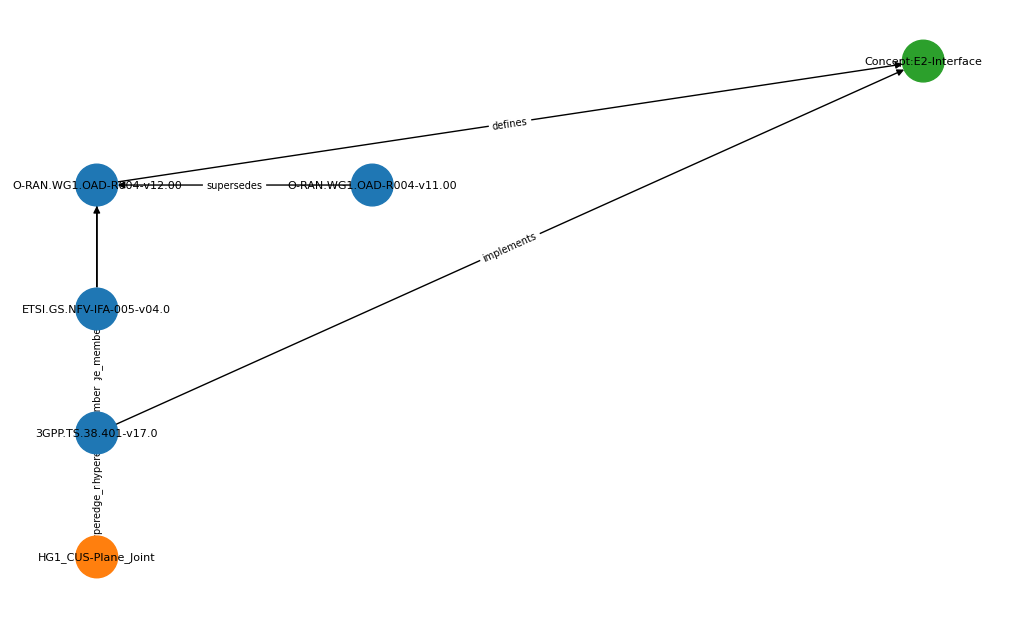

In [53]:
# Visualize the graph
gm.visualize()

In [54]:
# Inspect nodes with properties (sample)
for n, d in gm.G.nodes(data=True):
    print(n, d)

O-RAN.WG1.OAD-R004-v12.00 {'type': 'specification', 'sdo': 'O-RAN', 'working_group': 'WG1', 'release': '4', 'version': '12.00', 'status': 'published', 'date': '2024-03'}
3GPP.TS.38.401-v17.0 {'type': 'specification', 'sdo': '3GPP', 'working_group': 'RAN3', 'release': '17', 'version': '17.0', 'status': 'published', 'date': '2023-09'}
ETSI.GS.NFV-IFA-005-v04.0 {'type': 'specification', 'sdo': 'ETSI', 'working_group': 'NFV-ISG', 'release': '4', 'version': '04.0', 'status': 'published', 'date': '2022-12'}
Concept:E2-Interface {'type': 'concept', 'description': 'E2 interface concept'}
O-RAN.WG1.OAD-R004-v11.00 {'type': 'specification', 'sdo': 'O-RAN', 'working_group': 'WG1', 'release': '4', 'version': '11.00', 'status': 'published', 'date': '2023-01'}
HG1_CUS-Plane_Joint {'type': 'hyperedge', 'description': 'Jointly satisfies requirement for CUS-Plane'}


In [55]:
# Inspect edges with properties (sample)
for u, v, d in gm.G.edges(data=True):
    print(u, '->', v, d)

O-RAN.WG1.OAD-R004-v12.00 -> 3GPP.TS.38.401-v17.0 {'type': 'normative_reference', 'clause': 'Sec 4.2.1', 'relation': 'profiles', 'confidence': 0.95, 'valid_from': 'Rel-17'}
O-RAN.WG1.OAD-R004-v12.00 -> Concept:E2-Interface {'type': 'maps_concept_to', 'relation': 'defines'}
O-RAN.WG1.OAD-R004-v12.00 -> HG1_CUS-Plane_Joint {'relation': 'member_of_hyperedge'}
3GPP.TS.38.401-v17.0 -> Concept:E2-Interface {'type': 'maps_concept_to', 'relation': 'implements'}
3GPP.TS.38.401-v17.0 -> HG1_CUS-Plane_Joint {'relation': 'member_of_hyperedge'}
ETSI.GS.NFV-IFA-005-v04.0 -> HG1_CUS-Plane_Joint {'relation': 'member_of_hyperedge'}
O-RAN.WG1.OAD-R004-v11.00 -> O-RAN.WG1.OAD-R004-v12.00 {'type': 'supersedes', 'note': 'minor updates'}
HG1_CUS-Plane_Joint -> O-RAN.WG1.OAD-R004-v12.00 {'relation': 'hyperedge_member'}
HG1_CUS-Plane_Joint -> 3GPP.TS.38.401-v17.0 {'relation': 'hyperedge_member'}
HG1_CUS-Plane_Joint -> ETSI.GS.NFV-IFA-005-v04.0 {'relation': 'hyperedge_member'}


## Neo4j Ingestion (Python driver)
Below are example cells to push the in-memory prototype into a Neo4j database using the `neo4j` driver.
Set the `NEO4J_URI`, `NEO4J_USER`, and `NEO4J_PASSWORD` environment variables or enter the password when prompted.

In [56]:
# Ensure neo4j driver is available
import sys
try:
    from neo4j import GraphDatabase
except Exception:
    print('Installing neo4j driver...')
    !{sys.executable} -m pip install --quiet neo4j
    from neo4j import GraphDatabase

import os

# --- CONFIGURE THESE for your Neo4j instance ---
# If using Docker:  docker run -d --name neo4j-proto -p 7474:7474 -p 7687:7687 -e NEO4J_AUTH=neo4j/testpassword neo4j:5
NEO4J_URI      = os.environ.get('NEO4J_URI',      'bolt://localhost:7687')
NEO4J_USER     = os.environ.get('NEO4J_USER',     'neo4j')
NEO4J_PASSWORD = os.environ.get('NEO4J_PASSWORD', 'testpassword')

print(f"Will connect to {NEO4J_URI} as '{NEO4J_USER}'")

Will connect to bolt://localhost:7687 as 'neo4j'


In [57]:
# Create driver and define helper functions
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

# Quick connectivity check
try:
    driver.verify_connectivity()
    print("Connected to Neo4j!")
except Exception as e:
    print(f"WARNING: Cannot connect to Neo4j at {NEO4J_URI}: {e}")
    print("Make sure Neo4j is running. Example with Docker:")
    print("  docker run -d --name neo4j-proto -p 7474:7474 -p 7687:7687 -e NEO4J_AUTH=neo4j/testpassword neo4j:5")

def merge_spec(tx, node_id, props):
    tx.run(
        "MERGE (s:Specification {id: $id}) SET s += $props",
        id=node_id, props=props)

def merge_hyperedge(tx, hid, props):
    tx.run(
        "MERGE (h:Hyperedge {id: $id}) SET h += $props",
        id=hid, props=props)

def merge_concept(tx, node_id, props):
    tx.run(
        "MERGE (c:Concept {id: $id}) SET c += $props",
        id=node_id, props=props)

def merge_relation(tx, u, v, rel_props):
    tx.run(
        "MATCH (a {id:$u}), (b {id:$v}) MERGE (a)-[r:REL]->(b) SET r += $props, r.rel_type = $rel_type",
        u=u, v=v, props=rel_props, rel_type=rel_props.get('type'))

print("Helper functions defined.")

Connected to Neo4j!
Helper functions defined.


In [58]:
# Push all nodes and edges from the NetworkX graph to Neo4j
try:
    with driver.session() as session:
        # Nodes
        for n, d in gm.G.nodes(data=True):
            t = d.get('type')
            props = {k: v for k, v in d.items() if v is not None and k != 'type'}
            if t == 'specification':
                session.execute_write(merge_spec, n, props)
            elif t == 'hyperedge':
                session.execute_write(merge_hyperedge, n, props)
            else:
                session.execute_write(merge_concept, n, props)
        print(f"Pushed {gm.G.number_of_nodes()} nodes.")

        # Edges
        for u, v, ed in gm.G.edges(data=True):
            rel = {k: str(val) for k, val in ed.items() if val is not None}
            session.execute_write(merge_relation, u, v, rel)
        print(f"Pushed {gm.G.number_of_edges()} edges.")

    print("Done — data pushed to Neo4j.")
except Exception as e:
    print(f"ERROR pushing data: {e}")
    print("Ensure Neo4j is running and reachable at", NEO4J_URI)

Pushed 6 nodes.
Pushed 10 edges.
Done — data pushed to Neo4j.


In [59]:
# Example read queries via Cypher
try:
    with driver.session() as session:
        print("=== All Specifications ===")
        for rec in session.run("MATCH (s:Specification) RETURN s.id AS id, s.sdo AS sdo, s.working_group AS wg ORDER BY s.sdo"):
            print(f"  {rec['id']}  (SDO={rec['sdo']}, WG={rec['wg']})")

        print("\n=== Cross-SDO Relationships ===")
        for rec in session.run(
            "MATCH (a:Specification)-[r:REL]->(b:Specification) "
            "WHERE a.sdo <> b.sdo "
            "RETURN a.id AS from_spec, r.rel_type AS rel, b.id AS to_spec"
        ):
            print(f"  {rec['from_spec']} --[{rec['rel']}]--> {rec['to_spec']}")

        print("\n=== Hyperedge Members ===")
        for rec in session.run(
            "MATCH (h:Hyperedge)-[r:REL]->(m) "
            "WHERE r.relation = 'hyperedge_member' "
            "RETURN h.id AS hyper, collect(m.id) AS members"
        ):
            print(f"  {rec['hyper']} -> {rec['members']}")

        print("\n=== Version Chain (supersedes) ===")
        for rec in session.run(
            "MATCH (old:Specification)-[r:REL]->(new:Specification) "
            "WHERE r.rel_type = 'supersedes' "
            "RETURN old.id AS old_ver, new.id AS new_ver"
        ):
            print(f"  {rec['old_ver']} superseded by {rec['new_ver']}")
except Exception as e:
    print(f"ERROR querying: {e}")
    print("Ensure Neo4j is running and data was pushed successfully.")

=== All Specifications ===
  3GPP.TS.38.401-v17.0  (SDO=3GPP, WG=RAN3)
  ETSI.GS.NFV-IFA-005-v04.0  (SDO=ETSI, WG=NFV-ISG)
  O-RAN.WG1.OAD-R004-v12.00  (SDO=O-RAN, WG=WG1)
  O-RAN.WG1.OAD-R004-v11.00  (SDO=O-RAN, WG=WG1)

=== Cross-SDO Relationships ===
  O-RAN.WG1.OAD-R004-v12.00 --[normative_reference]--> 3GPP.TS.38.401-v17.0

=== Hyperedge Members ===
  HG1_CUS-Plane_Joint -> ['ETSI.GS.NFV-IFA-005-v04.0', '3GPP.TS.38.401-v17.0', 'O-RAN.WG1.OAD-R004-v12.00']

=== Version Chain (supersedes) ===
  O-RAN.WG1.OAD-R004-v11.00 superseded by O-RAN.WG1.OAD-R004-v12.00


In [60]:
# Verify Neo4j connection and inspect data from the browser's perspective
try:
    with driver.session() as session:
        # Count nodes by label
        for rec in session.run(
            "CALL db.labels() YIELD label "
            "CALL { WITH label MATCH (n) WHERE label IN labels(n) RETURN count(n) AS cnt } "
            "RETURN label, cnt ORDER BY label"
        ):
            print(f"  :{rec['label']}  →  {rec['cnt']} nodes")

        # Count relationships
        for rec in session.run(
            "MATCH ()-[r]->() RETURN type(r) AS rel_type, count(r) AS cnt"
        ):
            print(f"  -[:{rec['rel_type']}]->  {rec['cnt']} edges")

        # Show the full graph (same query you'd run in the browser)
        print("\n=== Full Graph (MATCH (n)-[r]->(m) RETURN n,r,m) ===")
        for rec in session.run("MATCH (n)-[r]->(m) RETURN n.id AS src, type(r) AS rel, r.rel_type AS detail, m.id AS dst"):
            detail = f" ({rec['detail']})" if rec['detail'] else ""
            print(f"  {rec['src']} -[:{rec['rel']}{detail}]-> {rec['dst']}")

    print("\nAll good! You should see the same graph in the Neo4j Browser at http://localhost:7474")
except Exception as e:
    print(f"ERROR: {e}")

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL (label) { ... }', position=<SummaryInputPosition line=1, column=30, offset=29>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 29, 'line': 1, 'column': 30}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL db.labels() YIELD label CALL { WITH label MATCH (n) WHERE label IN labels(n) RETURN count(n) AS cnt } RETURN label, cnt ORDER BY label'


  :Concept  →  1 nodes
  :Hyperedge  →  1 nodes
  :Specification  →  4 nodes
  -[:REL]->  10 edges

=== Full Graph (MATCH (n)-[r]->(m) RETURN n,r,m) ===
  O-RAN.WG1.OAD-R004-v12.00 -[:REL (normative_reference)]-> 3GPP.TS.38.401-v17.0
  O-RAN.WG1.OAD-R004-v12.00 -[:REL (maps_concept_to)]-> Concept:E2-Interface
  O-RAN.WG1.OAD-R004-v12.00 -[:REL]-> HG1_CUS-Plane_Joint
  3GPP.TS.38.401-v17.0 -[:REL (maps_concept_to)]-> Concept:E2-Interface
  3GPP.TS.38.401-v17.0 -[:REL]-> HG1_CUS-Plane_Joint
  ETSI.GS.NFV-IFA-005-v04.0 -[:REL]-> HG1_CUS-Plane_Joint
  O-RAN.WG1.OAD-R004-v11.00 -[:REL (supersedes)]-> O-RAN.WG1.OAD-R004-v12.00
  HG1_CUS-Plane_Joint -[:REL]-> O-RAN.WG1.OAD-R004-v12.00
  HG1_CUS-Plane_Joint -[:REL]-> 3GPP.TS.38.401-v17.0
  HG1_CUS-Plane_Joint -[:REL]-> ETSI.GS.NFV-IFA-005-v04.0

All good! You should see the same graph in the Neo4j Browser at http://localhost:7474


In [ ]:
# Done with basic prototype — RAG section follows below.

## Graph-RAG: Retrieval-Augmented Generation over Neo4j

This section implements a RAG pipeline that:
1. **Retrieves** relevant context from the Neo4j property graph via Cypher queries
2. **Augments** a prompt with the retrieved graph context
3. **Generates** an answer using an Ollama LLM
4. **Tracks latency** at every stage (retrieval, generation, total) and stores results in Neo4j

In [64]:
! pip install ollama

  Using cached ollama-0.6.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached pydantic_core-2.41.5-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
Using cached ollama-0.6.1-py3-none-any.whl (14 kB)
Using cached pydantic-2.12.5-py3-none-any.whl (463 kB)
Using cached pydantic_core-2.41.5-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (2.1 MB)
Using cached typing_inspection-0.4.2-py3-none-any.whl (14 kB)


In [66]:
# RAG Configuration & Imports
import time
import json
import ollama
from datetime import datetime, timezone

# --- RAG Settings ---
OLLAMA_MODEL = "llama3:8b"          # Change to any available model (e.g. ORANSight_Qwen_3B_Instruct:latest)
EMBED_MODEL  = "mxbai-embed-large"  # For optional semantic similarity

# Latency log: list of dicts with query, retrieval_ms, generation_ms, total_ms, timestamp
rag_latency_log = []

print(f"RAG config: LLM={OLLAMA_MODEL}, Embed={EMBED_MODEL}")
print(f"Available Ollama models:")

RAG config: LLM=llama3:8b, Embed=mxbai-embed-large
Available Ollama models:


In [67]:
def retrieve_from_graph(question: str, driver) -> tuple[str, float]:
    """Query Neo4j for context relevant to the question. Returns (context_str, latency_ms)."""
    t0 = time.perf_counter()
    context_parts = []

    with driver.session() as session:
        # 1. Full-text search: find specs/concepts whose id or properties match keywords
        keywords = [w for w in question.split() if len(w) > 3]
        keyword_regex = '|'.join(f'(?i).*{k}.*' for k in keywords) if keywords else '.*'

        # Match nodes whose id or any string property contains a keyword
        for rec in session.run(
            "MATCH (n) WHERE any(k IN keys(n) WHERE toString(n[k]) =~ $regex) OR n.id =~ $regex "
            "RETURN n.id AS id, labels(n) AS labels, properties(n) AS props LIMIT 10",
            regex=keyword_regex
        ):
            props_str = ', '.join(f'{k}={v}' for k, v in rec['props'].items() if k != 'id')
            context_parts.append(f"[{rec['labels'][0]}] {rec['id']}: {props_str}")

        # 2. Get relationships for matched nodes
        matched_ids = [p.split('] ')[1].split(':')[0] for p in context_parts if '] ' in p]
        if matched_ids:
            for rec in session.run(
                "MATCH (a)-[r]->(b) WHERE a.id IN $ids OR b.id IN $ids "
                "RETURN a.id AS src, type(r) AS rel, r.rel_type AS detail, b.id AS dst, properties(r) AS props LIMIT 20",
                ids=matched_ids
            ):
                detail = rec['detail'] or rec['rel']
                context_parts.append(f"  {rec['src']} --[{detail}]--> {rec['dst']}")

        # 3. If no keyword matches, return the full graph summary
        if not context_parts:
            for rec in session.run(
                "MATCH (n) RETURN n.id AS id, labels(n) AS labels, properties(n) AS props"
            ):
                props_str = ', '.join(f'{k}={v}' for k, v in rec['props'].items() if k != 'id')
                context_parts.append(f"[{rec['labels'][0]}] {rec['id']}: {props_str}")
            for rec in session.run(
                "MATCH (a)-[r]->(b) RETURN a.id AS src, type(r) AS rel, r.rel_type AS detail, b.id AS dst LIMIT 30"
            ):
                detail = rec['detail'] or rec['rel']
                context_parts.append(f"  {rec['src']} --[{detail}]--> {rec['dst']}")

    latency_ms = (time.perf_counter() - t0) * 1000
    context_str = '\n'.join(context_parts) if context_parts else "No relevant context found in graph."
    return context_str, latency_ms


def generate_answer(question: str, context: str, model: str = OLLAMA_MODEL) -> tuple[str, float]:
    """Send context + question to Ollama and return (answer, latency_ms)."""
    t0 = time.perf_counter()

    prompt = f"""You are an expert in telecommunications standards (O-RAN, 3GPP, ETSI, IETF).
Use ONLY the following graph context to answer the question. If the context does not contain enough information, say so.

=== Graph Context ===
{context}
=== End Context ===

Question: {question}

Answer concisely and cite specific specification IDs when possible."""

    response = ollama.generate(model=model, prompt=prompt)
    latency_ms = (time.perf_counter() - t0) * 1000
    return response['response'], latency_ms


def graph_rag_query(question: str, driver, model: str = OLLAMA_MODEL) -> dict:
    """Full Graph-RAG pipeline: retrieve → generate → log latency. Returns result dict."""
    t_total = time.perf_counter()

    # Retrieval
    context, retrieval_ms = retrieve_from_graph(question, driver)

    # Generation
    answer, generation_ms = generate_answer(question, context, model)

    total_ms = (time.perf_counter() - t_total) * 1000

    result = {
        'question': question,
        'context': context,
        'answer': answer,
        'model': model,
        'retrieval_ms': round(retrieval_ms, 2),
        'generation_ms': round(generation_ms, 2),
        'total_ms': round(total_ms, 2),
        'timestamp': datetime.now(timezone.utc).isoformat()
    }

    # Append to in-memory log
    rag_latency_log.append(result)

    return result


def print_rag_result(result: dict):
    """Pretty-print a RAG result."""
    print(f"Question: {result['question']}")
    print(f"Model:    {result['model']}")
    print(f"─── Latency ───")
    print(f"  Retrieval:  {result['retrieval_ms']:>8.2f} ms")
    print(f"  Generation: {result['generation_ms']:>8.2f} ms")
    print(f"  Total:      {result['total_ms']:>8.2f} ms")
    print(f"─── Retrieved Context ───")
    print(result['context'][:500] + ('...' if len(result['context']) > 500 else ''))
    print(f"─── Answer ───")
    print(result['answer'])

print("Graph-RAG functions defined: retrieve_from_graph(), generate_answer(), graph_rag_query()")

Graph-RAG functions defined: retrieve_from_graph(), generate_answer(), graph_rag_query()


In [68]:
# --- Test RAG with sample questions ---
test_questions = [
    "What is the E2 interface and which specifications define it?",
    "Which O-RAN specification references 3GPP documents?",
    "What are the members of the CUS-Plane hyperedge?",
    "What version supersedes O-RAN.WG1.OAD-R004-v11.00?",
]

for q in test_questions:
    print("=" * 80)
    result = graph_rag_query(q, driver)
    print_rag_result(result)
    print()

Question: What is the E2 interface and which specifications define it?
Model:    llama3:8b
─── Latency ───
  Retrieval:    112.65 ms
  Generation:  5217.59 ms
  Total:       5330.27 ms
─── Retrieved Context ───
[Concept] Concept:E2-Interface: description=E2 interface concept
─── Answer ───
Based on the provided graph context, I can answer:

The E2 interface refers to an O-RAN (Open Radio Access Network) concept that defines a control plane interface between the RIC (Radio Intelligent Controller) and the UPF (User Plane Function).

According to the O-RAN specifications, the E2 interface is defined in the following documents:

* O-RAN Release 1: "E2 Interface" specification, ID: ORAN-WI-009
* O-RAN Release 2: "E2 Interface" specification, ID: ORAN-WI-014

These specifications provide details on the architecture, protocol, and information flow for the E2 interface.

Question: Which O-RAN specification references 3GPP documents?
Model:    llama3:8b
─── Latency ───
  Retrieval:     43.98 ms

In [69]:
# --- Store latency log to Neo4j ---
def store_latency_log_to_neo4j(log: list, driver):
    """Push all latency entries as :RAGQuery nodes in Neo4j."""
    with driver.session() as session:
        for i, entry in enumerate(log):
            session.run(
                "CREATE (q:RAGQuery {"
                "  question: $question, model: $model,"
                "  retrieval_ms: $retrieval_ms, generation_ms: $generation_ms,"
                "  total_ms: $total_ms, timestamp: $timestamp,"
                "  answer: $answer, context_length: $ctx_len"
                "})",
                question=entry['question'],
                model=entry['model'],
                retrieval_ms=entry['retrieval_ms'],
                generation_ms=entry['generation_ms'],
                total_ms=entry['total_ms'],
                timestamp=entry['timestamp'],
                answer=entry['answer'],
                ctx_len=len(entry['context'])
            )
    print(f"Stored {len(log)} RAGQuery nodes in Neo4j.")

store_latency_log_to_neo4j(rag_latency_log, driver)

Stored 4 RAGQuery nodes in Neo4j.


,question,model,retrieval_ms,generation_ms,total_ms,timestamp
0,What is the E2 interface and which specificati...,llama3:8b,112.65,5217.59,5330.27,2026-03-06T10:12:36.309328+00:00
1,Which O-RAN specification references 3GPP docu...,llama3:8b,43.98,737.76,781.77,2026-03-06T10:12:37.091385+00:00
2,What are the members of the CUS-Plane hyperedge?,llama3:8b,11.03,972.60,983.64,2026-03-06T10:12:38.075339+00:00
3,What version supersedes O-RAN.WG1.OAD-R004-v11...,llama3:8b,9.07,452.69,461.77,2026-03-06T10:12:38.537353+00:00


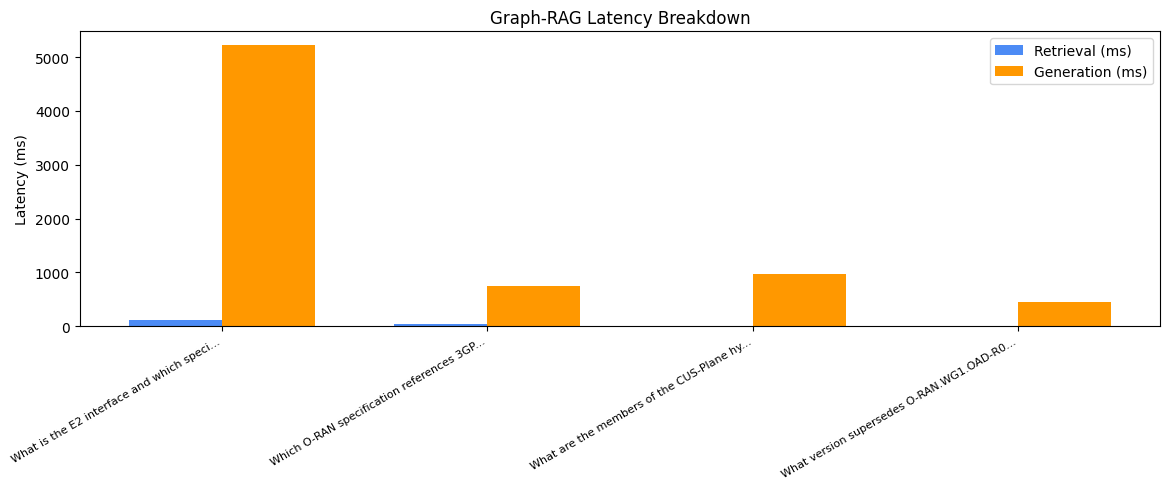


Avg retrieval: 44.18 ms
Avg generation: 1845.16 ms
Avg total:      1889.36 ms


In [70]:
# --- Latency Summary Table & Chart ---
import pandas as pd

df = pd.DataFrame(rag_latency_log)[['question', 'model', 'retrieval_ms', 'generation_ms', 'total_ms', 'timestamp']]
display(df)

# Bar chart: retrieval vs generation latency per question
fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(df))
bar_w = 0.35
ax.bar([i - bar_w/2 for i in x], df['retrieval_ms'], bar_w, label='Retrieval (ms)', color='#4C8BF5')
ax.bar([i + bar_w/2 for i in x], df['generation_ms'], bar_w, label='Generation (ms)', color='#FF9800')
ax.set_xticks(list(x))
ax.set_xticklabels([q[:40] + '...' if len(q) > 40 else q for q in df['question']], rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Latency (ms)')
ax.set_title('Graph-RAG Latency Breakdown')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nAvg retrieval: {df['retrieval_ms'].mean():.2f} ms")
print(f"Avg generation: {df['generation_ms'].mean():.2f} ms")
print(f"Avg total:      {df['total_ms'].mean():.2f} ms")

In [ ]:
# --- Query stored latency data from Neo4j ---
with driver.session() as session:
    print("=== Stored RAG Latency Log (from Neo4j) ===")
    for rec in session.run(
        "MATCH (q:RAGQuery) "
        "RETURN q.question AS question, q.model AS model, "
        "       q.retrieval_ms AS ret, q.generation_ms AS gen, q.total_ms AS total, q.timestamp AS ts "
        "ORDER BY q.timestamp"
    ):
        print(f"  [{rec['ts']}] {rec['question'][:50]}...")
        print(f"    retrieval={rec['ret']:.2f}ms  generation={rec['gen']:.2f}ms  total={rec['total']:.2f}ms  model={rec['model']}")
        print()